In [ ]:
import torch, pandas as pd, os, glob, re, lightning.pytorch as pl
import yaml
from sleepjepa.survival import PatchTFTSurvivalDemo,  make_cuts_days
from sleepjepa.slumber import SingleOutcomeDataset, ALL_FREQUENCY_FILTERS, ALL_CHANNELS, nested_tensor_sequence_multi_label_collate
from sleepjepa.jepa import JEPASimpleLightning, LeJEPALightning2
from sleepjepa.nested import get_predictions_nested_survival
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import DataLoader
from datetime import datetime

from sleepjepa.heads import AttentiveClassifier
from sleepjepa.augmentations import VariableChannelInput
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import WandbLogger
from pathlib import Path
import torch.nn as nn
import sys

torch.set_float32_matmul_precision('high')
torch.backends.cuda.enable_flash_sdp(True)

outcome_idx = sys.argv[1] if len(sys.argv) > 1 else None
# outcome index from job array
config_path = 'config/train_sleep_long_term_outcome.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

outcome_config_path = 'outcome_path_map.yaml'
with open(outcome_config_path, 'r') as f:
    outcome_paths = yaml.safe_load(f)

outcome_cols = ['cognitive_decline_label']
best_model_path = "" # fill in with modl path
time_cols = [f"{col}_time" for col in outcome_cols]

config['paths'].update(outcome_paths[outcome_cols[0]]) # update config with outcome specific paths

n_demographic_embeddings = config['dataset'].get('demographic_embeddings', [])
y_demographic_columns = config['dataset'].get('y_demographic_columns', [])
demographic_embeddings = dict(zip(y_demographic_columns, n_demographic_embeddings))

if not config['dataset'].get('demographic_predictor', False):
    #y_demographic_columns = []
    demographic_embeddings = {}

dataset_filename = config['paths']['dataset_filename']
models_dir = config['paths']['models_dir']

pretrained_encoder_path = os.path.join(config['paths']['encoder_dir'], config['paths']['pretrained_encoder_path'])

try:
    encoder_model = JEPASimpleLightning.load_from_checkpoint(pretrained_encoder_path, map_location='cpu')
    num_heads = encoder_model.encoder.predictor_blocks[0].self_attn.num_heads
    d_model = encoder_model.encoder.d_model
except:
    encoder_model = LeJEPALightning2.load_from_checkpoint(pretrained_encoder_path, map_location='cpu')
    num_heads = encoder_model.encoder.predictor_blocks[0].self_attn.num_heads#encoder_model.encoder.encoder.predictor_blocks[0].self_attn.num_heads
    d_model = encoder_model.encoder.d_model

# encoder_model = JEPASimpleLightning.load_from_checkpoint(pretrained_encoder_path, map_location='cpu')
# num_heads = encoder_model.encoder.predictor_blocks[0].self_attn.num_heads
# d_model = encoder_model.encoder.d_model

shhs_file_path = config['paths'].get('shhs_file_path', None)
mros_file_path = config['paths'].get('mros_file_path', None)
mesa_file_path = config['paths'].get('mesa_file_path', None)
wsc_file_path = config['paths'].get('wsc_file_path', None)
ds = ['SHHS', 'MROS', 'MESA', 'WSC']

outcome_dfs = []
ext_test_dfs = []
for n,f in zip(ds, [shhs_file_path, mros_file_path, mesa_file_path, wsc_file_path]):
    if f is not None:
        assert os.path.exists(f), f"File {f} does not exist."
        df = pd.read_csv(f)
        if n in config['paths']['ext_test_sets']:
            ext_test_dfs.append(df)
        else:
            outcome_dfs.append(df)
    else:
        continue
outcome_data = pd.concat(outcome_dfs).reset_index(drop=True)
if len(ext_test_dfs) > 0:
    ext_outcome_df = pd.concat(ext_test_dfs).reset_index(drop=True)

train_zarrs, val_zarrs, test_zarrs = [], [], []
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=config['run_config']['random_state'])
labels = outcome_data[outcome_cols[0]].values.tolist()
groups = [Path(i).stem for i in outcome_data.filepath.unique()]

if config['paths']['split_shhs_sleep_fm']:
    shhs_test_ids = pd.read_csv(config['paths']['shhs_sleepfm_ids'])['nsrrid'].unique().tolist()
    test_zarrs.extend(outcome_data[outcome_data['nsrrid'].isin(shhs_test_ids)]['filepath'].unique().tolist())
    df = outcome_data[~outcome_data['nsrrid'].isin(shhs_test_ids)].reset_index(drop=True)
    train_val_zarrs = outcome_data.filepath.unique().tolist()
else:
    train_idxs, test_idxs = next(splitter.split(X=outcome_data.filepath.unique(),  y=labels, groups=groups))
    train_val_zarrs = [outcome_data.filepath.unique()[i] for i in train_idxs]
    test_zarrs.extend([outcome_data.filepath.unique()[i] for i in test_idxs]) # add test zarrs
# further split train and val
labels = outcome_data[outcome_data['filepath'].isin(train_val_zarrs)][outcome_cols[0]].values.tolist()
groups = [Path(i).stem for i in train_val_zarrs]
splitter2 = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=config['run_config']['random_state'])
train_idxs, val_idxs = next(splitter2.split(X=train_val_zarrs,  y=labels, groups=groups))
train_zarrs.extend([train_val_zarrs[i] for i in train_idxs])
val_zarrs.extend([train_val_zarrs[i] for i in val_idxs])

print(f"Number of training samples: {len(train_zarrs)}")
print(f"Number of validation samples: {len(val_zarrs)}")
print(f"Number of test samples: {len(test_zarrs)}")
if len(ext_test_dfs) > 0:
    print(f"Number of external test samples: {len(ext_outcome_df.filepath.unique().tolist())}")

channels = ALL_CHANNELS
c_in = len(channels)

frequency = config['dataset']['frequency']

win_length=frequency*config['dataset']['patch_seconds'] 
hop_length=win_length - int(config['dataset']['overlap']*win_length)
max_seq_len_sec = config['dataset']['max_seq_len_sec'] # for dataloader
min_seq_len_sec = config['dataset']['min_seq_len_sec']
seq_len_sec = sample_stride = max_seq_len_sec # for dataloader
max_seq_len = seq_len_sec*frequency if seq_len_sec is not None else max_seq_len_sec*frequency # for model
n_patches = (max(max_seq_len, win_length)-win_length) // hop_length + 1
if ((max_seq_len-win_length) % hop_length != 0):
    n_patches += 1

num_classes = len(make_cuts_days(min_year=config['training']['time_range_years'][0], max_year=config['training']['time_range_years'][1], bin_years=config['training']['discrete_time_bins']))

lp_head = dict(embed_dim=d_model,
        num_heads=config['lp_head'].get('num_heads', num_heads),
        mlp_ratio=config['lp_head']['mlp_ratio'],
        depth=config['lp_head']['depth'],
        c_in=c_in,
        norm_layer=nn.LayerNorm,
        init_std=config['lp_head']['init_std'],
        qkv_bias=config['lp_head']['qkv_bias'],
        num_classes=num_classes,
        complete_block=config['lp_head']['complete_block'],
        #affine=config['lp_head']['affine'],
        per_channel=config['lp_head'].get('per_channel', False)
    )

lp_model = AttentiveClassifier(**lp_head)

scheduler_kwargs = config['scheduler'].copy()
del scheduler_kwargs['scheduler_type']

filename = f"{config['run_config']['name']}-{outcome_cols[0]}" + "{epoch:02d}-mean_ipcw_auc-{mean_ipcw_auc:.5f}-brier_score-{brier_score:.5f}-cindex_ipcw-{cindex_ipcw:.5f}-all_score-{all_score:.5f}"
date_str = datetime.now().strftime("%Y-%m-%d")

pl.seed_everything(config['run_config']['random_state'])

if Path(os.path.join(models_dir, f'{dataset_filename}-train_samples.csv.gz')).exists():
    train_ds_sample_df = pd.read_csv(os.path.join(models_dir, f'{dataset_filename}-train_samples.csv.gz'))
    train_zarrs = train_ds_sample_df['file'].values.tolist()
else:
    train_ds_sample_df = None

train_outcome_df = outcome_data[outcome_data['filepath'].isin(train_zarrs)].reset_index(drop=True)
age_col = config['dataset'].get('age_col', None)
age_idx = y_demographic_columns.index(age_col) if age_col in y_demographic_columns else None
if age_col is not None:
    y_demographic_norm_stats = {age_col: {'mean': train_outcome_df[age_col].mean(), 'std': train_outcome_df[age_col].std()}}
else:
    y_demographic_norm_stats = {}
print("Demographic normalization stats:", y_demographic_norm_stats)


if Path(os.path.join(models_dir, f'{dataset_filename}-test_samples.csv.gz')).exists():
    test_ds_sample_df = pd.read_csv(os.path.join(models_dir, f'{dataset_filename}-test_samples.csv.gz'))
    test_zarrs = test_ds_sample_df['file'].values.tolist()
else:
    test_ds_sample_df = None

test_ds = SingleOutcomeDataset(zarr_files=test_zarrs, 
                                            channels=channels, 
                                            max_seq_len_sec=max_seq_len_sec, 
                                            min_seq_len_sec=min_seq_len_sec,
                                            sample_seq_len_sec=seq_len_sec, 
                                            sample_stride_sec=sample_stride,
                                            y_outcome_df = outcome_data,
                                            sample_df=test_ds_sample_df,
                                            trim_wake_epochs=False,
                                            return_hypnogram_every_sec=30,
                                            hypnogram_padding_mask=-100,
                                            hypnogram_frequency=1,
                                            y_mapping_column='filepath',
                                            y_outcome=outcome_cols, 
                                            y_time_column=time_cols,
                                            y_demographic_columns=y_demographic_columns,
                                            y_demographic_norm_stats=y_demographic_norm_stats,
                                            include_partial_samples=config['dataset']['include_partial_samples'], 
                                            frequency=frequency,
                                            butterworth_filters=ALL_FREQUENCY_FILTERS,
                                            median_filter_kernel_size=None,
                                            voltage_channels=None,
                                            constant_nan_tolerance=config['dataset']['constant_nan_tolerance'],
                                            normalize_signals=config['dataset']['normalize_signals'],
                                            clip_interpolations=None)



patchmeup_model = PatchTFTSurvivalDemo.load_from_checkpoint(best_model_path, 
                                                                preloaded_model=encoder_model,
                                                                linear_probing_head=lp_model,
                                                                map_location='cpu')


.conda/envs/timeflies/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of training samples: 1947
Number of validation samples: 217
Number of test samples: 542


Seed set to 126


Demographic normalization stats: {'age_s1': {'mean': 76.05417956656346, 'std': 5.3367406530474115}}


In [ ]:
import torch
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
import torch.nn.functional as F

class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.feedforward = model.feedforward
        self.time_bias = model.time_bias

    def forward(self, X, risk_year_idx=-1):
        output = self.feedforward(X) + self.time_bias
        return output[:, [risk_year_idx]]

def extract_representation_attributions(model, X, target_class=0, risk_year_idx=-1):
    """
    Compute IG attributions from encoder representations to output
    
    Returns:
        attributions: [batch, n_channels, seq_len, d_model] - attribution per representation element
    """
    model.eval()
    
    with torch.no_grad():
        X = model.encoder(X)
        if isinstance(X, tuple):
            X = X[0]
    
    rep_wrapper = ModelWrapper(model)
    
    baseline = torch.zeros_like(X)
    
    ig = IntegratedGradients(rep_wrapper, multiply_by_inputs=True)
    X.requires_grad = True
    
    attributions = ig.attribute(
        X,
        additional_forward_args=(risk_year_idx,),
        n_steps=512,
        target=target_class,
        internal_batch_size=8
    )
    
    return attributions

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

torch.cuda.empty_cache()
test_sample_idx = sample_idx 
year_sample_idx = int(time_yr)

target_class = 0

channels = ['ECG', 'EOG(L)', 'EMG', 'EEG', 'SaO2', 'THOR RES', 'ABDO RES']
X, y, time, demographics = test_ds[test_sample_idx]
X = X.unsqueeze(0)
baseline = torch.zeros_like(X)

pathmeup_model = patchmeup_model.to('cuda:0')
X = X.to('cuda:0')

rep_attributions = extract_representation_attributions(
    patchmeup_model, 
    X, 
    target_class=target_class,
    risk_year_idx=year_sample_idx
)

/tmp/ipykernel_342431/2020624385.py:75: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  year_sample_idx = int(time_yr)


In [6]:
def aggregate_representation_attributions(rep_attributions):
    """
    Aggregate representation attributions to patch-level importance
    
    rep_attributions: [batch, n_channels, seq_len, d_model]
    Returns: [n_channels, seq_len] - importance per patch
    """
    # Sum absolute attribution across d_model dimension
    patch_importance = rep_attributions.abs().sum(dim=-1)  # [batch, n_channels, seq_len]
    return patch_importance.squeeze(0).cpu().numpy()  # [n_channels, seq_len]

(7, 14400)
(7, 14400)


/tmp/ipykernel_342431/3842035893.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


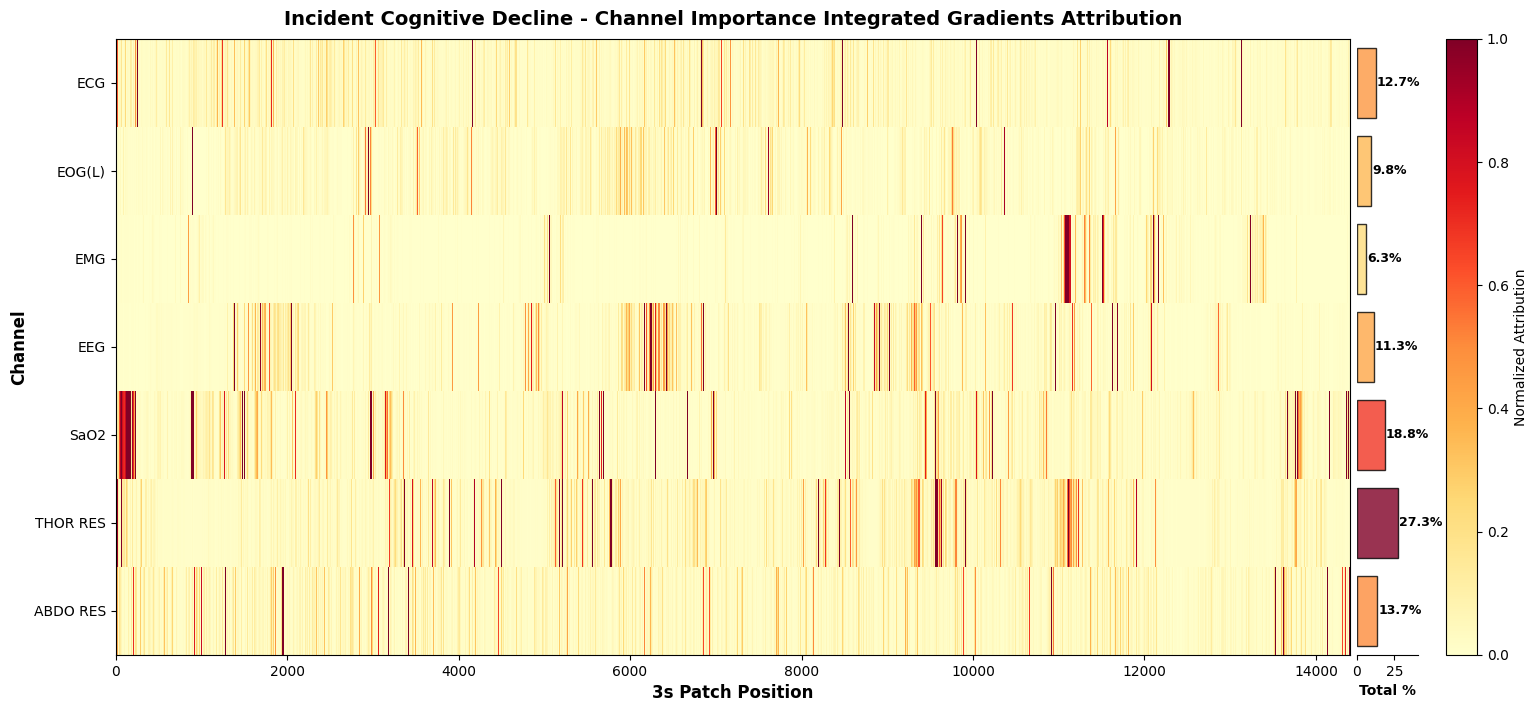

In [ ]:
def plot_temporal_channel_importance(attention_scores, rep_attributions, channels):
    """
    Plot combined temporal and channel importance as aligned heatmaps with channel percentages
    """
    
    ig_importance = aggregate_representation_attributions(rep_attributions)
    print(ig_importance.shape)
    ig_per_channel = ig_importance.sum(axis=1)
    ig_pct = 100 * ig_per_channel / ig_per_channel.sum()
    
    global_max = ig_importance.max()
    ig_normalized = ig_importance / global_max if global_max > 0 else ig_importance
    
    percentile_99 = np.percentile(ig_importance, 99.)
    ig_normalized = np.clip(ig_importance / percentile_99, 0, 1)
    print(ig_normalized.shape)

    fig = plt.figure(figsize=(18, 8))
    gs = fig.add_gridspec(1, 2, width_ratios=[20, 1], wspace=0.01)
    ax_channel = fig.add_subplot(gs[0, 0])
    ax_pct = fig.add_subplot(gs[0, 1], sharey=ax_channel)
    
    im = ax_channel.imshow(ig_normalized, aspect='auto', cmap='YlOrRd', 
                          interpolation='nearest', vmin=0, vmax=1)
    ax_channel.set_yticks(range(len(channels)))
    ax_channel.set_yticklabels(channels, fontsize=10)
    ax_channel.set_xlabel('3s Patch Position', fontsize=12, fontweight='bold')
    ax_channel.set_ylabel('Channel', fontsize=12, fontweight='bold')
    ax_channel.set_title(f'{outcome_paths[outcome_cols[0]]["pretty_name"]} - Channel Importance Integrated Gradients Attribution', 
                        fontsize=14, fontweight='bold', pad=10)
    
    colors_bar = plt.cm.YlOrRd(ig_pct / ig_pct.max())
    ax_pct.barh(range(len(channels)), ig_pct, color=colors_bar, 
                alpha=0.8, edgecolor='black', height=0.8)
    ax_pct.set_xlim(0, ig_pct.max() * 1.5)
    ax_pct.set_xlabel('Total %', fontsize=10, fontweight='bold')
    ax_pct.tick_params(axis='y', left=False, labelleft=False)
    ax_pct.spines['left'].set_visible(False)
    ax_pct.spines['top'].set_visible(False)
    ax_pct.spines['right'].set_visible(False)
    
    for i, pct in enumerate(ig_pct):
        ax_pct.text(pct + ig_pct.max() * 0.02, i, f'{pct:.1f}%', 
                   va='center', ha='left', fontsize=9, fontweight='bold')
    
    cbar = plt.colorbar(im, ax=[ax_channel, ax_pct], 
                       label='Normalized Attribution', 
                       pad=0.02, fraction=0.046)
    
    plt.tight_layout()
    return fig


fig1 = plot_temporal_channel_importance(
    None, 
    rep_attributions.detach().cpu(), 
    channels
)

